In [1]:
#%load_ext autoreload%autoreload 2
from Network import Network, Layer
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.set_default_device("cpu")

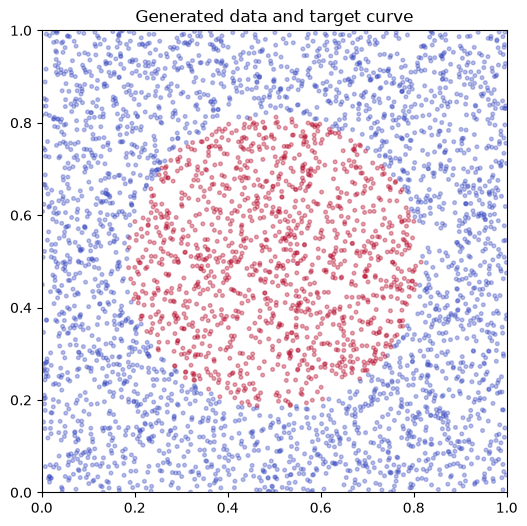

In [2]:
# Generate points and labels for y = 0.3sin(5pix)+0.5
num_points = 4000
X = torch.rand(num_points, 2)
# curve_y = 0.3 * torch.sin(5 * torch.pi * X[:, 0]) + 0.5
y = ((X[:, 0]-0.5)**2 + (X[:, 1]-0.5) ** 2 < 0.1).long()

# x_line = torch.linspace(0, 1, 400)
# curve_line = 0.3 * torch.sin(5 * torch.pi * x_line) + 0.5

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap="coolwarm", s=7, alpha=0.35)
# plt.plot(x_line.cpu(), curve_line.cpu(), color="black", linewidth=2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Generated data and target curve")
plt.show()


In [3]:
# Use torch modules to split into train and test data
dataset = TensorDataset(X, y)
mini_batch_size = 1000
train_loader = DataLoader(dataset, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator(torch.get_default_device()))


In [4]:
# SGD network using the custom Network class
sine_network = Network()
sine_network.layers.append(Layer(2, 5))
# sine_network.layers.append(Layer(30, 10))
sine_network.layers.append(Layer(5,5))

sine_network.layers.append(Layer(5, 2, torch.nn.Identity()))

loss_fn = torch.nn.CrossEntropyLoss()
learning_rate = 200
epochs = 1000

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    train_x, train_y = next(iter(train_loader))
    sine_network.calculate_with_gradient(train_x, train_y, loss_function=loss_fn)
    sine_network.update_weights(learning_rate)

    
    train_logits = sine_network.calculate(X)

    # peak copilot code
    train_losses.append(loss_fn(train_logits, y).item())
    train_preds = torch.argmax(train_logits, dim=1)
    test_accuracies.append((train_preds == y).float().mean().item())
    # print(test_accuracies[-1])

print(f"Final test accuracy: {test_accuracies[-1]:.4f}")
# 

Final test accuracy: 0.9810


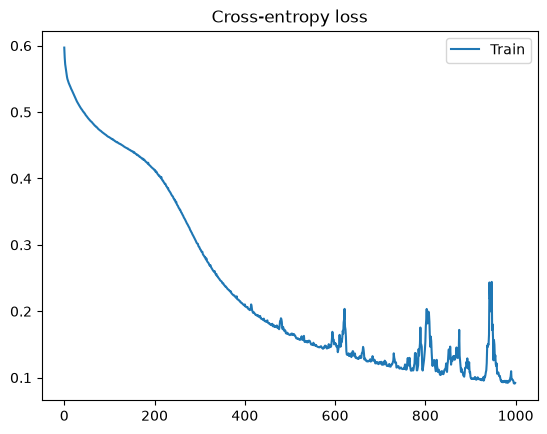

In [5]:
plt.plot(range(len(train_losses)), train_losses, label="Train")
plt.title("Cross-entropy loss")
plt.legend()
plt.show()


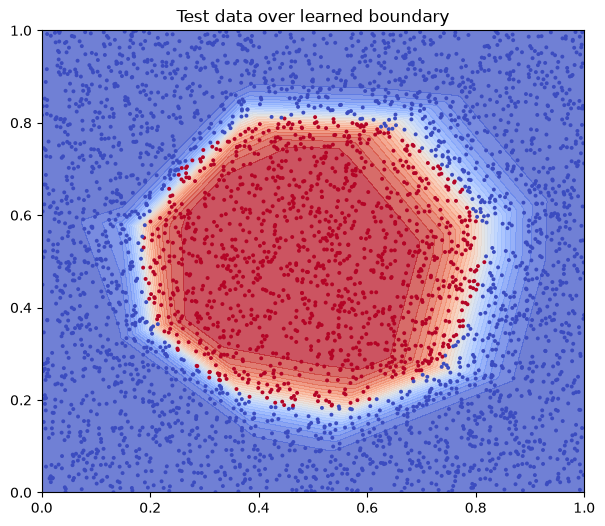

In [6]:
# Visualize learned decision surface
logit_grid, xs, ys = sine_network.calculate_rectangle((0, 0), (1, 1), 250)
prob_grid = torch.softmax(logit_grid, dim=-1)[:, :, 1]

plt.figure(figsize=(7, 6))
plt.contourf(xs.cpu().numpy(), ys.cpu().numpy(), prob_grid.cpu().numpy(), levels=30, cmap="coolwarm", alpha=0.75)
plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap="coolwarm", s=8, edgecolor="none")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Test data over learned boundary")
plt.show()


(<Figure size 1200x1500 with 27 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 2'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>, <Axes: >]], dtype=object))

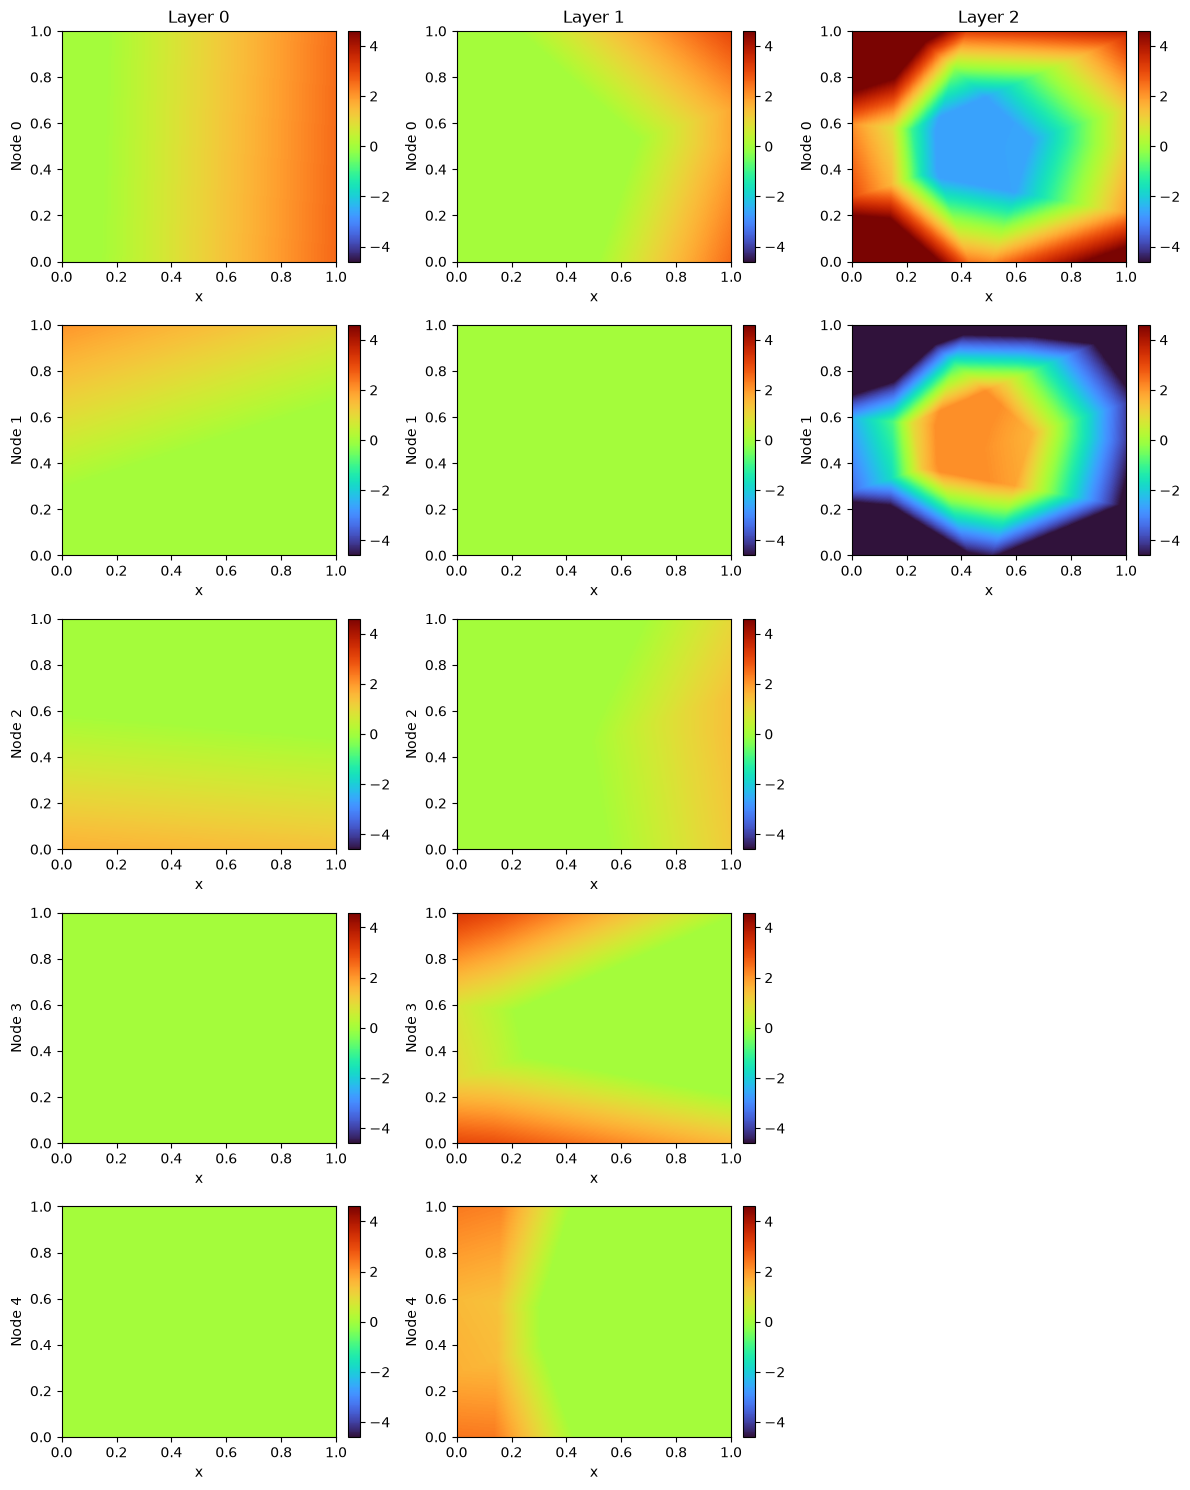

In [7]:
sine_network.plot_all_layer_heatmaps()          